In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('ford.csv')

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [6]:
df.shape

(17966, 9)

In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [9]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(154)

In [11]:
# Find duplicate rows 
# keep=False marks all occurrences of a duplicate as True
duplicates = df[df.duplicated(keep=False)]
duplicates

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
25,Focus,2017,18499,Manual,13063,Petrol,145,41.5,2.0
27,Fiesta,2015,8299,Manual,25935,Petrol,0,65.7,1.0
28,Fiesta,2018,12499,Manual,8700,Petrol,145,58.9,1.0
113,Focus,2016,10995,Manual,30923,Diesel,0,74.3,1.5
159,Focus,2016,10995,Manual,30923,Diesel,0,74.3,1.5
...,...,...,...,...,...,...,...,...,...
15127,EcoSport,2019,16799,Automatic,433,Petrol,150,45.6,1.0
15684,KA,2008,1795,Manual,63000,Petrol,160,45.6,1.3
15685,KA,2008,1795,Manual,63000,Petrol,160,45.6,1.3
17607,B-MAX,2017,11495,Automatic,5000,Petrol,145,44.1,1.6


In [12]:
#Remove duplicate values
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(17812, 9)

In [15]:
df.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [16]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

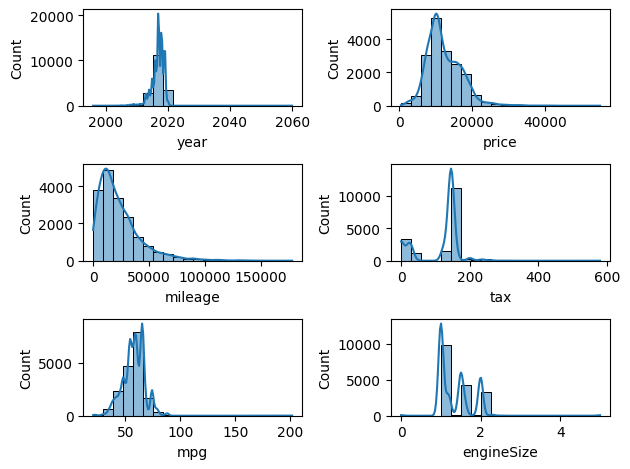

In [17]:
def plotting(var,num):      
    plt.subplot(3,2,num)    
    sns.histplot(df[var], kde=True, bins=20)

plotting('year',1)
plotting('price',2)
plotting('mileage',3)
plotting('tax',4)
plotting('mpg',5)
plotting('engineSize',6)

plt.tight_layout()     #To avoid overlapping of graphs

<Axes: xlabel='model', ylabel='count'>

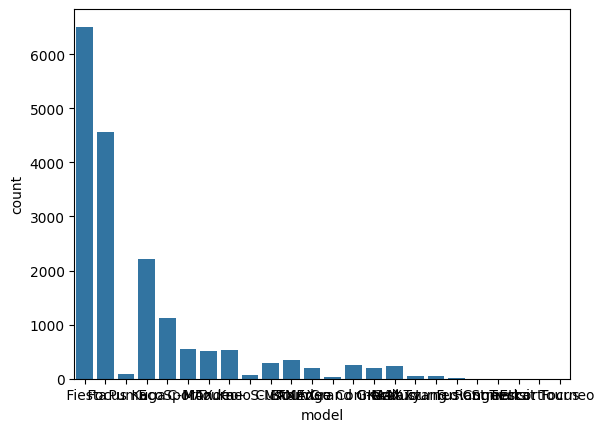

In [18]:
sns.countplot(x = df['model'])

### Let's check why model graph is getting overlapped the reason could be that there are many different models thus due to less space they are written one above the other so first lets check how many types of models are there

In [19]:
df['model'].value_counts()

model
 Fiesta                   6509
 Focus                    4555
 Kuga                     2208
 EcoSport                 1127
 C-MAX                     542
 Ka+                       523
 Mondeo                    512
 B-MAX                     350
 S-MAX                     294
 Grand C-MAX               247
 Galaxy                    227
 Edge                      205
 KA                        197
 Puma                       79
 Tourneo Custom             69
 Mustang                    57
 Grand Tourneo Connect      57
 Tourneo Connect            32
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

### the reason was correct that i thought so the solution to this is that we rotate the graph's x and y axis

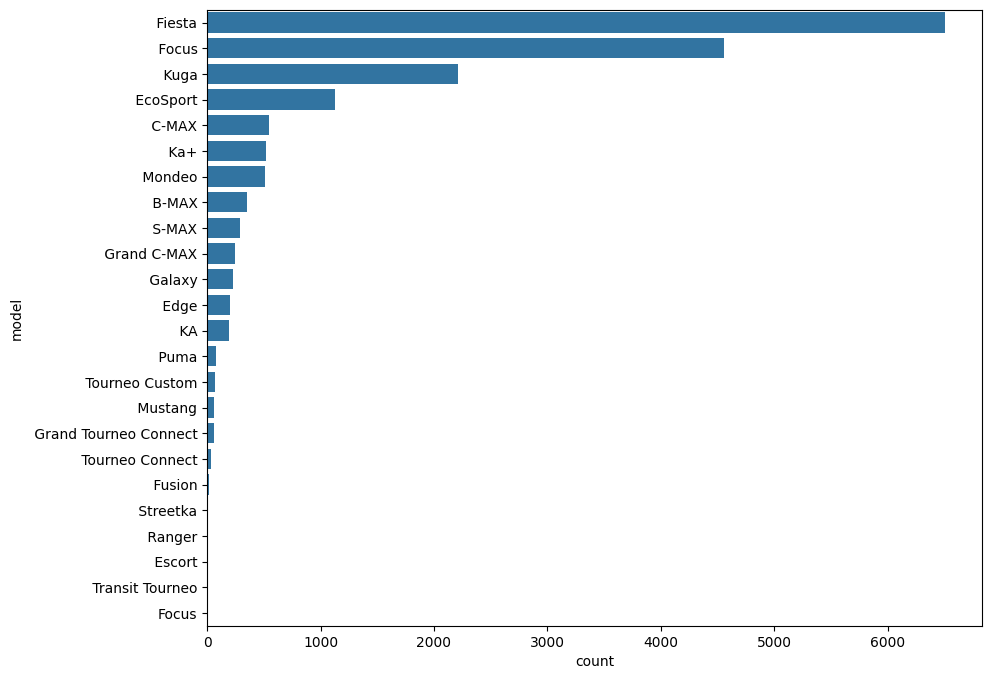

In [20]:
plt.figure(figsize=(10, 8))

# Switch x for y to make it horizontal
sns.countplot(data=df, y='model', order=df['model'].value_counts().index)

plt.show()

### In our bar chart, those "0" values (likely for models like the Streetka, Ranger, or Escort) mean those models have a very low count—sometimes just 1 or 2 cars—in a dataset of nearly 18,000. On a scale that goes up to 6,000 (for the Fiesta), a bar of 1 looks like zero.

## Solution to this:
### group all the tiny-count models into a single category called "Other". This keeps the data accurate without cluttering the x-axis with 20 different names.

### When I gave the csv file to gemini it noticed that some **blank** spaces are printed before data beacuse of which the data looks like this:
* `" Fiesta"`
* `" Focus"`
* `" Kuga"`
### Thus we have to remove these white spaces too

In [21]:
# 1. Clean the spaces from the model names first
df['model'] = df['model'].str.strip()

# 2. Identify models with fewer than 50 occurrences
model_counts = df['model'].value_counts()
small_models = model_counts[model_counts < 50].index

# 3. Replace them in the same dataframe
df.loc[df['model'].isin(small_models), 'model'] = 'others'

In [22]:
df['model'].value_counts()

model
Fiesta                   6509
Focus                    4556
Kuga                     2208
EcoSport                 1127
C-MAX                     542
Ka+                       523
Mondeo                    512
B-MAX                     350
S-MAX                     294
Grand C-MAX               247
Galaxy                    227
Edge                      205
KA                        197
Puma                       79
Tourneo Custom             69
Mustang                    57
Grand Tourneo Connect      57
others                     53
Name: count, dtype: int64

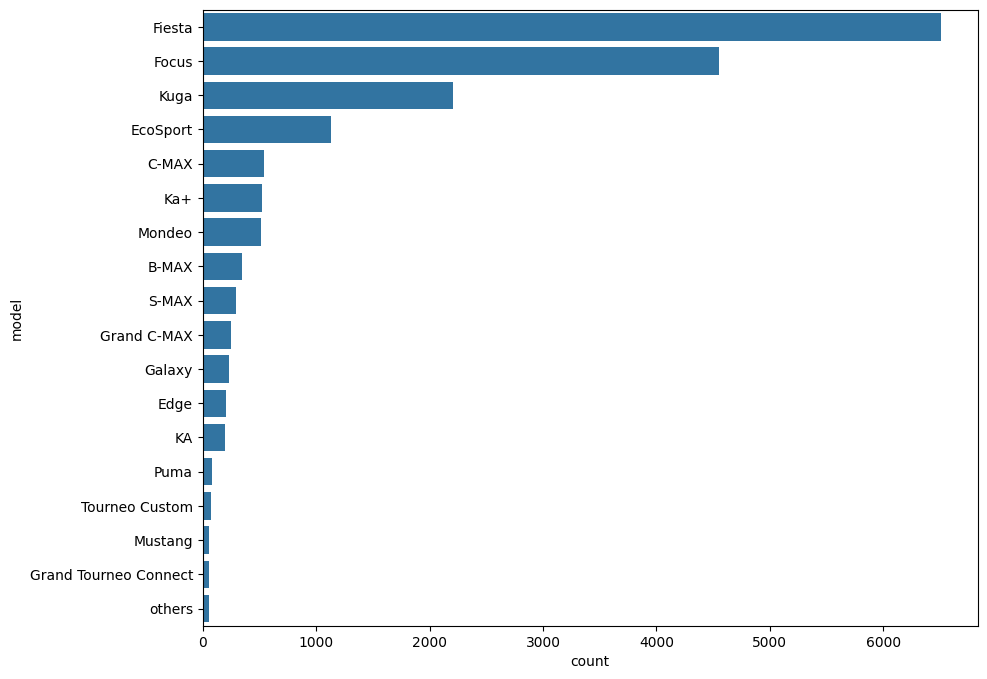

In [23]:
plt.figure(figsize=(10, 8))

# Switch x for y to make it horizontal
sns.countplot(data=df, y='model', order=df['model'].value_counts().index)

plt.show()

<Axes: xlabel='transmission', ylabel='count'>

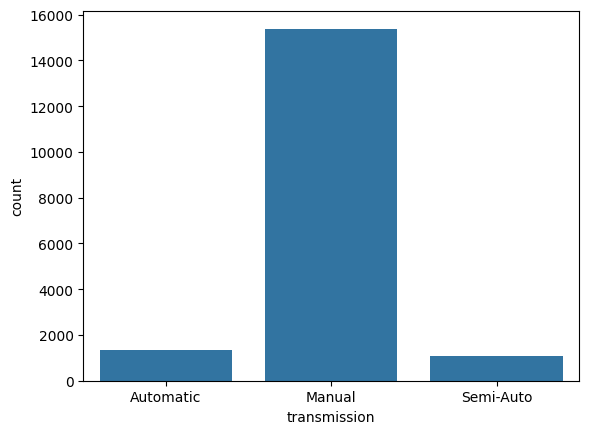

In [24]:
sns.countplot(x = df['transmission'])

<Axes: xlabel='fuelType', ylabel='count'>

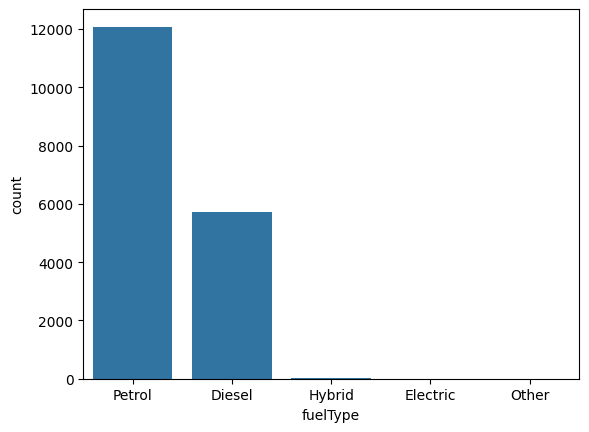

In [25]:
sns.countplot(x = df['fuelType'])

<Axes: >

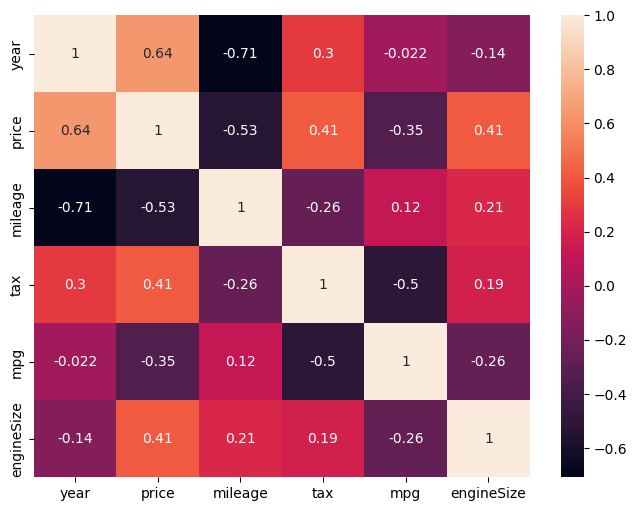

In [26]:
plt.figure(figsize= (8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

### I noticed some issues in tax graph so lets see that as tax is highly correlated to price hence we need to adress the issue

<Axes: xlabel='tax', ylabel='Count'>

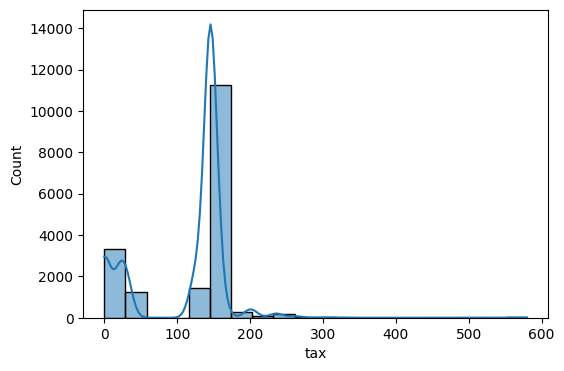

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['tax'], kde=True, bins=20)

That graph shows what we call a **bimodal distribution** (two main humps). It’s not necessarily "bad," but it tells a very specific story about our data that a machine learning model might find confusing if we don't handle it right.

### Will it cause problems?

**Yes and No.** Here is the breakdown:

* **The Problem:** Most simple linear models (like Linear Regression) "expect" data to follow a normal distribution (a single bell curve). Because your data has two separate peaks—one at **£0–£30** and another at **£145**—a model might try to predict the "average" (around £80-£100), even though almost no cars in your dataset actually have that tax price!
* **The "Why":** This is because of the 2017 tax law change. The tax isn't a random smooth number; it's a **categorical rule** disguised as a number.

---

### How to fix it for an accurate model:

If we are trying to predict **Price**, having **Tax** look like this is actually a valuable signal, but we can make it easier for the model by doing this:

1. **Feature Engineering (Best Fix):**
Create a new column called `is_pre_2017`. Since the tax jump happened on a specific date, telling the model "This car is from the old tax era" helps it understand why the tax is so low without getting confused by the "gap" in the graph.
```python
df['is_old_tax_regime'] = (df['year'] < 2017).astype(int)

```


## But before doing this we have to complete **Data Cleaning and Preprocessing task first**

In [28]:
df_cleaned = df.copy()

In [29]:
df_cleaned

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


### We can directly convert all the object data types columns to numerical at same time by below code

In [30]:
df_cleaned = pd.get_dummies(df, drop_first=True)

In [31]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,...,model_Puma,model_S-MAX,model_Tourneo Custom,model_others,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,14000,9083,150,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,13000,12456,150,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,17500,10460,145,40.3,1.5,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,16500,1482,145,48.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47.1,1.4,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,7499,40700,30,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,9999,7010,20,67.3,1.6,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,8299,5007,145,57.7,1.2,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


### All are converted to true and false so now we have to convert it to integers

In [32]:
df_cleaned = df_cleaned.astype(int)

In [33]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,...,model_Puma,model_S-MAX,model_Tourneo Custom,model_others,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,7499,40700,30,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,8299,5007,145,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


## Now it's turn for **Feature Engineering** to solve the Tax graph issue

### What the Feature Engineering Code looks like:

We create one column where **$1$ means "New System"** and **$0$ means "Old System"**.

```python
# 1 = New Tax (2017 and later), 0 = Old Tax (Before 2017)
df_cleaned['is_new_tax_system'] = (df_cleaned['year'] >= 2017).astype(int)

```

### How this "solves" your Tax Graph problem:

When the machine learning model looks at your data now, it doesn't just see a weird jump in tax values. It sees:

1. **If `is_new_tax_system` is $0$:** "Okay, I should expect the Tax to be low ($£0, £20, £30$)."
2. **If `is_new_tax_system` is $1$:** "Okay, I should expect the Tax to be high ($£145$ or $£150$)."

By adding this one column, you've given the model the **context** it needs to understand why the tax distribution has those two separate humps.

### Results from your data:

I ran a quick check on your file with this new column, and here is what it found:

* **Old System ($0$):** Average tax is around **$£71$**.
* **New System ($1$):** Average tax is around **$£132$**.

This confirms that the "hump" on the right side of your graph is dominated by the newer cars!

In [34]:
df_cleaned['is_new_tax_system'] = (df_cleaned['year'] >= 2017).astype(int)

In [35]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,...,model_S-MAX,model_Tourneo Custom,model_others,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,is_new_tax_system
0,2017,12000,15944,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
3,2019,17500,10460,145,40,1,0,0,0,1,...,0,0,0,1,0,0,0,0,1,1
4,2019,16500,1482,145,48,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
17962,2014,7499,40700,30,57,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
17964,2018,8299,5007,145,57,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1


## Now we have to perform Feature Scaling

In [36]:
df_cleaned.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'model_C-MAX',
       'model_EcoSport', 'model_Edge', 'model_Fiesta', 'model_Focus',
       'model_Galaxy', 'model_Grand C-MAX', 'model_Grand Tourneo Connect',
       'model_KA', 'model_Ka+', 'model_Kuga', 'model_Mondeo', 'model_Mustang',
       'model_Puma', 'model_S-MAX', 'model_Tourneo Custom', 'model_others',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol',
       'is_new_tax_system'],
      dtype='object')

In [37]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['mileage', 'tax', 'mpg','year']
scaler = StandardScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

In [38]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,...,model_S-MAX,model_Tourneo Custom,model_others,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,is_new_tax_system
0,0.067059,12000,-0.382994,0.591380,-0.042291,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
1,0.554393,14000,-0.736317,0.591380,-0.042291,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
2,0.067059,13000,-0.562616,0.591380,-0.042291,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
3,1.041726,17500,-0.665405,0.510777,-1.720193,1,0,0,0,1,...,0,0,0,1,0,0,0,0,1,1
4,1.041726,16500,-1.127749,0.510777,-0.930592,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,8999,-0.344061,0.591380,-1.029292,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
17962,-1.394942,7499,0.891875,-1.343079,-0.042291,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
17963,-0.907608,9999,-0.843071,-1.504284,0.944711,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
17964,0.554393,8299,-0.946220,0.510777,-0.042291,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1


## Now turn for Feature Extraction

### Person Correlation (for numerical features correlation with price)

In [39]:
correlation_with_charges = df_cleaned.corr(method='pearson')['price'].sort_values(ascending=False)

In [40]:
correlation_with_charges

price                          1.000000
year                           0.635715
is_new_tax_system              0.502164
engineSize                     0.495567
tax                            0.405969
model_Kuga                     0.281926
model_Mustang                  0.267520
model_Edge                     0.237867
model_S-MAX                    0.147319
transmission_Semi-Auto         0.140648
model_Galaxy                   0.133839
model_Puma                     0.129067
model_Tourneo Custom           0.117139
model_Focus                    0.112438
fuelType_Hybrid                0.073356
model_Grand Tourneo Connect    0.029859
model_EcoSport                 0.010959
fuelType_Electric              0.007759
fuelType_Other                 0.002421
model_Mondeo                  -0.000385
model_others                  -0.028728
model_Grand C-MAX             -0.034752
model_C-MAX                   -0.088128
model_Ka+                     -0.131120
model_KA                      -0.157703


### Here the numeric features are ['mileage', 'tax', 'mpg', 'year', 'engineSize'] and as per **Person Correlation** they are highly correlated with **price** so we have to keep all these columns.
## Now its turn for checking categoric features correlation with **price** so for that we will use **Chi-Square Test**

In [41]:
cat_features = ['model_C-MAX',
       'model_EcoSport', 'model_Edge', 'model_Fiesta', 'model_Focus',
       'model_Galaxy', 'model_Grand C-MAX', 'model_Grand Tourneo Connect',
       'model_KA', 'model_Ka+', 'model_Kuga', 'model_Mondeo', 'model_Mustang',
       'model_Puma', 'model_S-MAX', 'model_Tourneo Custom', 'model_others',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol',
       'is_new_tax_system']
alpha = 0.05

from scipy.stats import chi2_contingency
import pandas as pd

#Step 2
# Bin the target variable
df_cleaned['price_bin'] = pd.qcut(df_cleaned['price'], q=4, labels=False)

#Step 2.5
# Run Chi-Square test
chi2_results = {}

#Step 3
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['price_bin'])

    #Step 4
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    #Step 5
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'

    #Step 6
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

#Step 7
# Convert to DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_new_tax_system,6186.166364,0.0,Reject Null (Keep Feature)
model_Fiesta,2406.030837,0.0,Reject Null (Keep Feature)
model_Kuga,1810.873504,0.0,Reject Null (Keep Feature)
transmission_Manual,921.709747,0.0,Reject Null (Keep Feature)
fuelType_Petrol,816.312589,0.0,Reject Null (Keep Feature)
model_Edge,607.229537,0.0,Reject Null (Keep Feature)
model_Ka+,589.504436,0.0,Reject Null (Keep Feature)
model_Focus,534.764234,0.0,Reject Null (Keep Feature)
model_KA,472.422587,0.0,Reject Null (Keep Feature)
model_S-MAX,426.335539,0.0,Reject Null (Keep Feature)


### So we have to remove "model_Mondeo", "fuelType_Electric" and "fuelType_Other" from our dataset so the new dataset will be as shown below

In [42]:
final_df = df_cleaned[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'model_C-MAX',
       'model_EcoSport', 'model_Edge', 'model_Fiesta', 'model_Focus',
       'model_Galaxy', 'model_Grand C-MAX', 'model_Grand Tourneo Connect',
       'model_KA', 'model_Ka+', 'model_Kuga', 'model_Mustang',
       'model_Puma', 'model_S-MAX', 'model_Tourneo Custom', 'model_others',
       'transmission_Manual', 'transmission_Semi-Auto',
       'fuelType_Hybrid', 'fuelType_Petrol',
       'is_new_tax_system']]

In [43]:
final_df

,year,price,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,...,model_Mustang,model_Puma,model_S-MAX,model_Tourneo Custom,model_others,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Petrol,is_new_tax_system
0,0.067059,12000,-0.382994,0.591380,-0.042291,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
1,0.554393,14000,-0.736317,0.591380,-0.042291,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
2,0.067059,13000,-0.562616,0.591380,-0.042291,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,1.041726,17500,-0.665405,0.510777,-1.720193,1,0,0,0,1,...,0,0,0,0,0,1,0,0,1,1
4,1.041726,16500,-1.127749,0.510777,-0.930592,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,8999,-0.344061,0.591380,-1.029292,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
17962,-1.394942,7499,0.891875,-1.343079,-0.042291,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
17963,-0.907608,9999,-0.843071,-1.504284,0.944711,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
17964,0.554393,8299,-0.946220,0.510777,-0.042291,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1


In [44]:
final_df.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'model_C-MAX',
       'model_EcoSport', 'model_Edge', 'model_Fiesta', 'model_Focus',
       'model_Galaxy', 'model_Grand C-MAX', 'model_Grand Tourneo Connect',
       'model_KA', 'model_Ka+', 'model_Kuga', 'model_Mustang', 'model_Puma',
       'model_S-MAX', 'model_Tourneo Custom', 'model_others',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Hybrid',
       'fuelType_Petrol', 'is_new_tax_system'],
      dtype='object')

## Training & Testing of model

In [45]:
from sklearn.model_selection import train_test_split

x = final_df.drop('price', axis = 1)
y = final_df['price']  

In [46]:
X_train, X_test, y_train, y_test = train_test_split(                        #X_train=>80% of data stored in x , X_test=>20% of data stored in x, y_train=>80% of data stored in y, y_test=>20% of data stored in y
                                                    x,
                                                    y, 
                                                    test_size=0.2,          # This means 20% goes to the test pile!
                                                    random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [48]:
 y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

0.8245747674234123

In [50]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
adjusted_r2

0.823284876007408

In [51]:
y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)

print(f"Trained Score (Train R2): {r2_train}")
print(f"Test Score (Test R2): {r2}") 

Trained Score (Train R2): 0.8459538256251561
Test Score (Test R2): 0.8245747674234123


### Looking at our results:

- **Train R² = 0.846**  
- **Test R² = 0.825**  
- **Adjusted R² = 0.823**

Here’s what these numbers tell us:

### ✅ Strengths
- **High R² values**: Both train and test scores are above 0.8, which means your model explains more than 80% of the variance in the target variable. That’s generally considered strong performance for regression tasks.  
- **Close train vs. test scores**: The train score (0.846) is only slightly higher than the test score (0.825). This suggests your model is not overfitting — it generalizes well to unseen data.  
- **Adjusted R² is close to R²**: The adjusted R² (0.823) is very close to the test R² (0.825), meaning your model isn’t bloated with irrelevant features. The predictors are genuinely contributing.

### ⚠️ Things to keep in mind
- **Not perfect**: An R² of ~0.82 means ~18% of the variance is still unexplained. Depending on your domain, that might be acceptable or might signal room for improvement.  
- **Context matters**: In fields like finance or social sciences, an R² above 0.8 is excellent. In physics or engineering, sometimes models are expected to be even tighter.  
- **Residual analysis**: R² alone doesn’t tell the full story. Checking residual plots, error distributions, or metrics like RMSE/MAE can reveal if there are systematic errors.  

### 🎯 Verdict
Your model is **solid and well-balanced** — it generalizes well, avoids overfitting, and achieves strong explanatory power. I’d call it a “nice” model indeed. If you want to push it further, you could explore feature engineering, regularization, or ensemble methods, but as it stands, this is a very respectable result.

Would you like me to walk you through **how to interpret residuals and error metrics** next, so you can double-check if your model is not missing hidden patterns?


In [56]:
import joblib

# 1. Save your Linear Regression model
joblib.dump(model, 'car_price_model.pkl')

# 2. Save your Scaler (Important: your model expects scaled data!)
joblib.dump(scaler, 'scaler.pkl')

# 3. Save the exact column names the model expects
model_columns = list(x.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("All files saved! You should see 3 .pkl files in your folder.")

All files saved! You should see 3 .pkl files in your folder.
